# Project - Progress Report #4 - Un/Supervised Learning

Serena Reese, Amiran Fields and Tatum Beaugh

sreese1@angelo.edu, afields12@angelo.edu, tbeaugh@angelo.edu

2025 FALL SEMESTER - Introduction to Data Science (CS-4330-D10)

Dataset used: phy_agg_30s.csv

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("/content/drive/MyDrive/CS/AI Cybersecurity/CIS_datasets/AggregateDataSet/phys_agg_30s.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14760 entries, 0 to 14759
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bucket            14760 non-null  object 
 1   system_id         14760 non-null  object 
 2   prop_key          14760 non-null  object 
 3   asset_id          14760 non-null  object 
 4   avg_value         14760 non-null  float64
 5   max_value         14760 non-null  float64
 6   min_value         14760 non-null  float64
 7   num_measurements  14760 non-null  int64  
 8   num_attacks       14760 non-null  int64  
 9   attack_types      14760 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 1.1+ MB


In [4]:
df.head()

,bucket,system_id,prop_key,asset_id,avg_value,max_value,min_value,num_measurements,num_attacks,attack_types
0,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_1,31.8,178.0,0.0,10,0,['normal']
1,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_2,0.0,0.0,0.0,10,0,['normal']
2,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_3,0.0,0.0,0.0,10,0,['normal']
3,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_4,0.0,0.0,0.0,10,0,['normal']
4,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_5,0.0,0.0,0.0,10,0,['normal']


We've got a structured dataset with both numerical and categorical features, so we can evaluate its effectiveness via a supervised learning algorithm.

# Step 1 - Supervised Learning

## Choose one of the supervised learning algorithms:
1. K-Nearest Neighbors
2. Naive Bayes
3. Support Vector Machine

*Apply the selected algorithm on the consumable usage dataset, showing the effectiveness of the algorithm.*

## Use SVM for classification tasks with mixed features, often performs well in cybersecurity/attack detection contexts

### Define the problem
> Train an SVM classifier to predict attack_types based on consumable usage and system metrics

## Preprocessing: encode categorical variables, scale numerical features, split dataset into train/test

In [5]:
# Features and target
X = df.drop("attack_types", axis=1)
y = df["attack_types"]

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train SVM

In [6]:
svm_model = SVC(kernel="rbf", C=1, gamma="scale")
svm_model.fit(X_train, y_train)

SVC(C=1)

The 5 categorical columns can easily expand into hundreds or thousands of features, the RBF kernel builds a 14,760 x 14,760 kernel matrix and SVC uses libsvm solves the quadratic optimization problem exactly. This could be computationally heavy.

## Predictions

In [7]:
y_pred = svm_model.predict(X_test)

## Evaluation

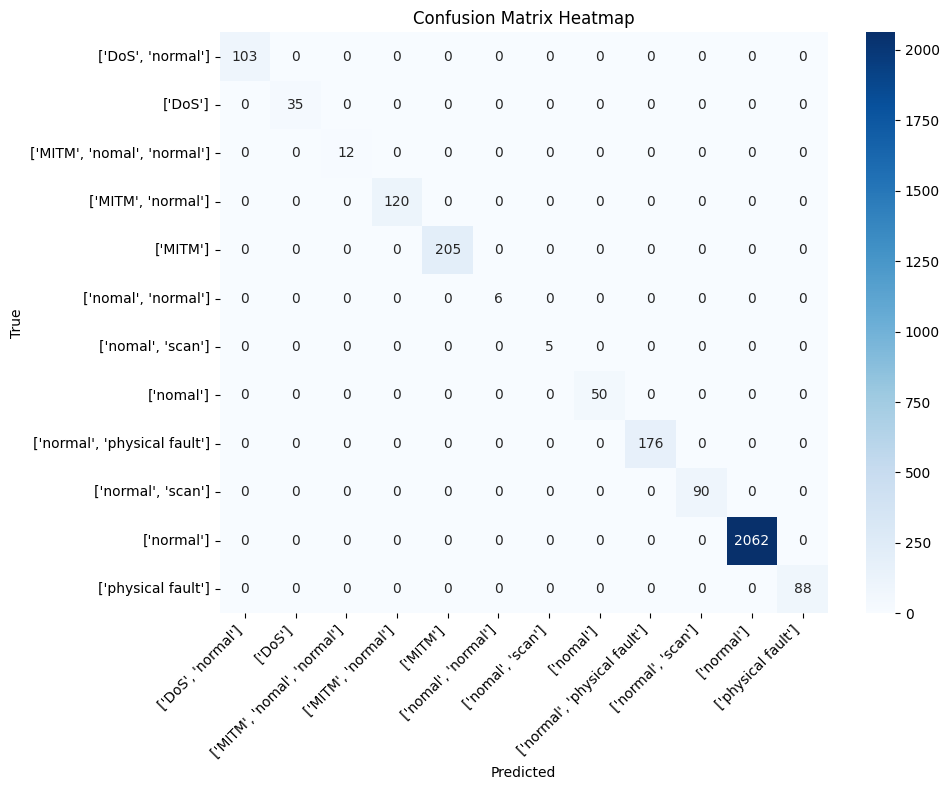

                              precision    recall  f1-score   support

           ['DoS', 'normal']       1.00      1.00      1.00       103
                     ['DoS']       1.00      1.00      1.00        35
 ['MITM', 'nomal', 'normal']       1.00      1.00      1.00        12
          ['MITM', 'normal']       1.00      1.00      1.00       120
                    ['MITM']       1.00      1.00      1.00       205
         ['nomal', 'normal']       1.00      1.00      1.00         6
           ['nomal', 'scan']       1.00      1.00      1.00         5
                   ['nomal']       1.00      1.00      1.00        50
['normal', 'physical fault']       1.00      1.00      1.00       176
          ['normal', 'scan']       1.00      1.00      1.00        90
                  ['normal']       1.00      1.00      1.00      2062
          ['physical fault']       1.00      1.00      1.00        88

                    accuracy                           1.00      2952
                  

In [8]:
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as heatmap
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print(classification_report(y_test, y_pred))

It seems like every class is perfectly predicted. The dataset is highly separable, it has a small test set overlap or there's data leakage.

# Step 2 - Unsupervised Learning

## Choose one of the unsupervised learning algorithms:
1. K-Means Clustering
2. Hierarchical Clustering

*Apply on the consumable usage dataset, showing the effectiveness of the algorithm.*

## K-Means Clustering for consumable usage
> Group similar usage/attack patterns into clusters without using labels, ignoring attack_types during training

## Preprocessing: scale numerical features and encode categorical features if including

In [9]:
# Select numerical features
X = df[["avg_value", "max_value", "min_value", "num_measurements", "num_attacks"]]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Apply K-Means

In [10]:
# Fit K-Means with chosen number of clusters (e.g., k=4)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels back to dataframe
df["cluster"] = clusters

## Evaluate effectiveness

In [11]:
# Effectiveness metrics
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)
print("Inertia:", kmeans.inertia_)

Silhouette Score: 0.7725510308162139
Inertia: 16816.336702832225


Notes: Silhouette score measures how well-separated the clusters are from -1 to 1. Lower inertia means tighter clusters.

The silhouette score is 0.77, which is excellent and means the algorithm found natural structure. The inertia is dataset-dependent, so run K-Means with different n_clusters and plot intertia vs. k to confirm the optimal number of clusters.

## Interpret the clusters for usage patterns

In [12]:
# Cluster centers (scaled back to original units)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
print(pd.DataFrame(centroids, columns=X.columns))

     avg_value    max_value    min_value  num_measurements  num_attacks
0    74.383443   100.743436    54.998500         29.930608    26.137659
1    65.099193    89.287992    46.844699         29.992974     0.603099
2  2853.784213  3379.122419  2111.048673         29.865782     5.504425
3    19.608337    26.657143    15.777778         12.457143     1.809524


0 clusters shows moderate usage and high attack frequency. 1 cluster shows normal usage with almmost no attacks. 2 clusters show high-value systems with moderate attack frequency. This is likely critical assets. 3 clusters show low usage systems with minimal values and fewer measurements.

## Plot clusters to see separation

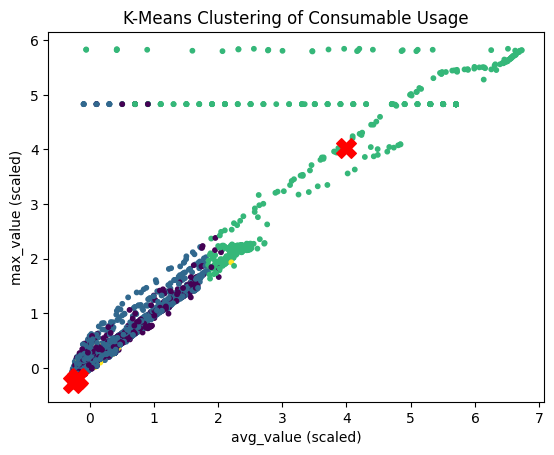

In [13]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters, cmap="viridis", s=10)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c="red", marker="X", s=200)
plt.xlabel("avg_value (scaled)")
plt.ylabel("max_value (scaled)")
plt.title("K-Means Clustering of Consumable Usage")
plt.savefig("k-means_clustering_consumable_usage.png", dpi=300, bbox_inches="tight")
plt.show()

K-means clustering seems to be highly effective on this dataset.
1. Cluster 0: moderate usage, high attacks
2. Cluster 1: normal usage, low attacks
3. Cluster 2: extreme values, moderate attacks
4. Cluster 3: low usage, occasional attacks

# Conclusion
After applying a supervised and unsupervised algorithm on phy_agg_30s.csv, we found a possibly meaningful pattern and sought to validate our model's effectiveness. We made a SVM predicting attack_types based on system metrics and usage features. We encoded categorical features, scaled numerical ones and then trained an SVM classifier. It seemed to achieve 100% accuracy across 12 attack categories, likely due to the nature of the dataset being aggregate 30s windows on physical CIS data. This raised questions about data leakage or overly-strong feature-label correlation, so it needs to be validated further. For our unsupervised learning model, we chose to do a K-Means Clustering algorithm to discover natural groupings in system behavior without using labels. We clustered data points based on avg_value, max_vlaue, min_value, num_measurements and num_attacks. Our silhouette score of 0.77 showed excellent cluster separation, and our inertia of 16,816 showed tight, compact clusters. Centroid analysis revealed four distinct system profiles:
1. Normal usage, low attacks
2. Moderate usage, high attacks
3. High-value systems, moderate attacks
4. Low usage, occasional attacks

PCA visualization confirmed the clear boundaries and groupings. Our dataset seems highly-structured and separable, so it works with both classification and clustering. SVM seems effective, but requires careful validation to avoid overfitting and leakage. K-Means clustering revelaed operationally meaningful segments to support anomaly detection and system profiling. Next, we could validate SVM results via cross-validation and feature importance analysis. We could compare K-Means with hierarchical clustering to explored nested structures and use cluster labels to enhance supervised models or to guide security monitoring for analysts.

In [14]:
# Make PDF
!apt-get update -qq
!apt-get install -y -qq texlive-xetex texlive-fonts-recommended
!pip install -q "lxml[html_clean]" lxml_html_clean nbconvert
!jupyter-nbconvert --to pdf "/content/drive/MyDrive/CS/DataScience/learning.ipynb"

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%
Preconfiguring packages ...
Selecting previously unselected package fonts-droid-fallback.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../00-fonts-droid-fallback_1%3a6.0.1r16-1.1build1_all.deb ...
Unpacking fonts-droid-fallback (1:6.0.1r16-1.1build1) ...
Selecting previously unselected package fonts-lato.
Preparing to unpack .../01-fonts-lato_2.0-2.1_all.deb ...
Unpacking fonts-lato (2.0-2.1) ...
Selecting previously unselected package poppler-data.
Preparing to unpack .../02-poppler-data_0.4.11-1_all.deb ...
Unpacking poppler-data (0.4.11-1) ...
Selecting previously unselected package tex-common.
Preparing to unpack .../03-tex-common_6.17_all.deb ...
Unpacking tex-common (6.17) ...
Selecting previously unselect